In [1]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
kredit = pd.read_csv("kredit.csv")
kredit

,id,pendapatan,pengeluaran
0,1,3.5,8.0
1,2,7.2,6.5
2,3,12.0,4.2
3,4,9.8,9.0
4,5,5.6,3.0
5,6,15.0,10.5
6,7,18.5,7.2
7,8,10.1,5.5
8,9,6.3,8.5
9,10,13.7,4.0


In [3]:
# Fungsi Keanggotaan Pendapatan (dalam juta)
def membershipPendapatan(x):
    pendapatan = {"Rendah": 0, "Sedang": 0, "Tinggi": 0}
    # Rendah
    if x <= 5:
        pendapatan["Rendah"] = 1
    elif 5 < x < 10:
        pendapatan["Rendah"] = (10 - x) / 5
    # Sedang
    if 5 < x < 10:
        pendapatan["Sedang"] = (x - 5) / 5
    elif 10 <= x <= 15:
        pendapatan["Sedang"] = (15 - x) / 5
    # Tinggi
    if x >= 15:
        pendapatan["Tinggi"] = 1
    elif 10 < x < 15:
        pendapatan["Tinggi"] = (x - 10) / 5
    return pendapatan

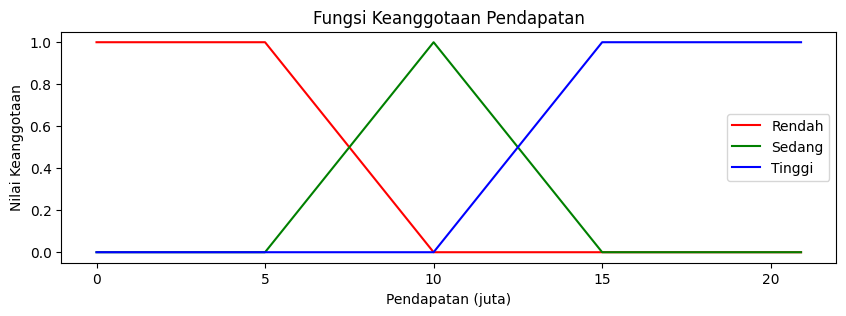

In [4]:
# Diagram pendapatan
plt.figure(figsize=(10,3))
x = np.arange(0, 21, 0.1)
plt.plot(x, [membershipPendapatan(i)["Rendah"] for i in x], 'r', label="Rendah")
plt.plot(x, [membershipPendapatan(i)["Sedang"] for i in x], 'g', label="Sedang")
plt.plot(x, [membershipPendapatan(i)["Tinggi"] for i in x], 'b', label="Tinggi")
plt.title("Fungsi Keanggotaan Pendapatan")
plt.xlabel("Pendapatan (juta)")
plt.ylabel("Nilai Keanggotaan")
plt.legend()
plt.savefig("membership_pendapatan.png", dpi=300,  bbox_inches='tight')
plt.show()

In [5]:
# Fungsi Keanggotaan Pengeluaran (dalam juta)
def membershipPengeluaran(x):
    pengeluaran = {"Rendah": 0, "Sedang": 0, "Tinggi": 0}
    # Rendah
    if x <= 4:
        pengeluaran["Rendah"] = 1
    elif 4 < x < 8:
        pengeluaran["Rendah"] = (8 - x) / 4
    # Sedang
    if 4 < x < 8:
        pengeluaran["Sedang"] = (x - 4) / 4
    elif 8 <= x <= 12:
        pengeluaran["Sedang"] = (12 - x) / 4
    # Tinggi
    if x >= 12:
        pengeluaran["Tinggi"] = 1
    elif 8 < x < 12:
        pengeluaran["Tinggi"] = (x - 8) / 4
    return pengeluaran

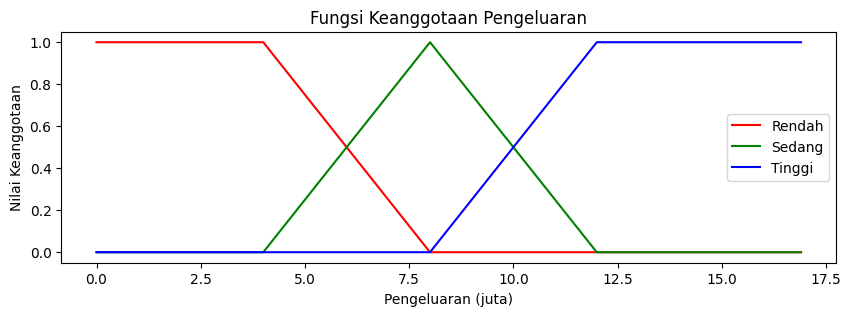

In [6]:
# Diagram pengeluaran
plt.figure(figsize=(10,3))
x = np.arange(0, 17, 0.1)
plt.plot(x, [membershipPengeluaran(i)["Rendah"] for i in x], 'r', label="Rendah")
plt.plot(x, [membershipPengeluaran(i)["Sedang"] for i in x], 'g', label="Sedang")
plt.plot(x, [membershipPengeluaran(i)["Tinggi"] for i in x], 'b', label="Tinggi")
plt.title("Fungsi Keanggotaan Pengeluaran")
plt.xlabel("Pengeluaran (juta)")
plt.ylabel("Nilai Keanggotaan")
plt.legend()
plt.savefig("membership_pengeluaran.png", dpi=300,  bbox_inches='tight')
plt.show()

## 1. Fuzzifikasi

In [7]:
# Fuzzifikasi
kumpulanNilaiFuzzy = []
for p, e in zip(kredit['pendapatan'], kredit['pengeluaran']):
    nilaiFuzzy = {
        "Pendapatan": p,
        "Pengeluaran": e,
        "Nilai Fuzzy Pendapatan": membershipPendapatan(p),
        "Nilai Fuzzy Pengeluaran": membershipPengeluaran(e)
    }
    kumpulanNilaiFuzzy.append(nilaiFuzzy)

In [8]:
hasil_pendapatan = []
hasil_pengeluaran = []

for i, row in kredit.iterrows():
    p = row['pendapatan']
    e = row['pengeluaran']

    fuzzy_p = membershipPendapatan(p)
    fuzzy_e = membershipPengeluaran(e)

    hasil_pendapatan.append({
        'id': row['id'],
        'pendapatan': p,
        'μPendapatan_Rendah': round(fuzzy_p['Rendah'], 3),
        'μPendapatan_Sedang': round(fuzzy_p['Sedang'], 3),
        'μPendapatan_Tinggi': round(fuzzy_p['Tinggi'], 3)
    })

    hasil_pengeluaran.append({
        'id': row['id'],
        'pengeluaran': e,
        'μPengeluaran_Rendah': round(fuzzy_e['Rendah'], 3),
        'μPengeluaran_Sedang': round(fuzzy_e['Sedang'], 3),
        'μPengeluaran_Tinggi': round(fuzzy_e['Tinggi'], 3)
    })

# Konversi jadi dua DataFrame
fuzzifikasi_pendapatan_df = pd.DataFrame(hasil_pendapatan)
fuzzifikasi_pengeluaran_df = pd.DataFrame(hasil_pengeluaran)

# Tampilkan kedua tabel
print("\n Hasil Fuzzifikasi Pendapatan")
display(fuzzifikasi_pendapatan_df)

print("\n Hasil Fuzzifikasi Pengeluaran")
display(fuzzifikasi_pengeluaran_df)


 Hasil Fuzzifikasi Pendapatan


,id,pendapatan,μPendapatan_Rendah,μPendapatan_Sedang,μPendapatan_Tinggi
0,1.0,3.5,1.00,0.00,0.00
1,2.0,7.2,0.56,0.44,0.00
2,3.0,12.0,0.00,0.60,0.40
3,4.0,9.8,0.04,0.96,0.00
4,5.0,5.6,0.88,0.12,0.00
5,6.0,15.0,0.00,0.00,1.00
6,7.0,18.5,0.00,0.00,1.00
7,8.0,10.1,0.00,0.98,0.02
8,9.0,6.3,0.74,0.26,0.00
9,10.0,13.7,0.00,0.26,0.74



 Hasil Fuzzifikasi Pengeluaran


,id,pengeluaran,μPengeluaran_Rendah,μPengeluaran_Sedang,μPengeluaran_Tinggi
0,1.0,8.0,0.000,1.000,0.000
1,2.0,6.5,0.375,0.625,0.000
2,3.0,4.2,0.950,0.050,0.000
3,4.0,9.0,0.000,0.750,0.250
4,5.0,3.0,1.000,0.000,0.000
5,6.0,10.5,0.000,0.375,0.625
6,7.0,7.2,0.200,0.800,0.000
7,8.0,5.5,0.625,0.375,0.000
8,9.0,8.5,0.000,0.875,0.125
9,10.0,4.0,1.000,0.000,0.000


In [9]:
print("\nContoh Hasil Fuzzifikasi:\n")
for i in range(5):
    idx = random.randint(0, len(kredit)-1)
    print(f"Pendapatan: {kumpulanNilaiFuzzy[idx]['Pendapatan']} juta")
    print(f"Pengeluaran: {kumpulanNilaiFuzzy[idx]['Pengeluaran']} juta")
    print(f"Nilai Fuzzy Pendapatan: {kumpulanNilaiFuzzy[idx]['Nilai Fuzzy Pendapatan']}")
    print(f"Nilai Fuzzy Pengeluaran: {kumpulanNilaiFuzzy[idx]['Nilai Fuzzy Pengeluaran']}\n")


Contoh Hasil Fuzzifikasi:

Pendapatan: 9.8 juta
Pengeluaran: 9.0 juta
Nilai Fuzzy Pendapatan: {'Rendah': 0.039999999999999855, 'Sedang': 0.9600000000000002, 'Tinggi': 0}
Nilai Fuzzy Pengeluaran: {'Rendah': 0, 'Sedang': 0.75, 'Tinggi': 0.25}

Pendapatan: 12.0 juta
Pengeluaran: 4.2 juta
Nilai Fuzzy Pendapatan: {'Rendah': 0, 'Sedang': 0.6, 'Tinggi': 0.4}
Nilai Fuzzy Pengeluaran: {'Rendah': 0.95, 'Sedang': 0.050000000000000044, 'Tinggi': 0}

Pendapatan: 15.0 juta
Pengeluaran: 10.5 juta
Nilai Fuzzy Pendapatan: {'Rendah': 0, 'Sedang': 0.0, 'Tinggi': 1}
Nilai Fuzzy Pengeluaran: {'Rendah': 0, 'Sedang': 0.375, 'Tinggi': 0.625}

Pendapatan: 7.2 juta
Pengeluaran: 6.5 juta
Nilai Fuzzy Pendapatan: {'Rendah': 0.5599999999999999, 'Sedang': 0.44000000000000006, 'Tinggi': 0}
Nilai Fuzzy Pengeluaran: {'Rendah': 0.375, 'Sedang': 0.625, 'Tinggi': 0}

Pendapatan: 13.7 juta
Pengeluaran: 4.0 juta
Nilai Fuzzy Pendapatan: {'Rendah': 0, 'Sedang': 0.2600000000000001, 'Tinggi': 0.7399999999999999}
Nilai Fuzzy Pe

## 2. Inferensi Fuzzy

In [10]:
# Aturan fuzzy
fuzzySetRules = {
    ('Rendah', 'Tinggi'): 'Tidak Layak',
    ('Rendah', 'Sedang'): 'Tidak Layak',
    ('Rendah', 'Rendah'): 'Layak Bersyarat',
    ('Sedang', 'Tinggi'): 'Tidak Layak',
    ('Sedang', 'Sedang'): 'Layak Bersyarat',
    ('Sedang', 'Rendah'): 'Layak',
    ('Tinggi', 'Tinggi'): 'Layak Bersyarat',
    ('Tinggi', 'Sedang'): 'Layak',
    ('Tinggi', 'Rendah'): 'Layak',
}

In [11]:
from IPython.display import display

aturan_df = pd.DataFrame(
    [(k[0], k[1], v) for k, v in fuzzySetRules.items()],
    columns=["Pendapatan", "Pengeluaran", "Kelayakan"]
)

print("Tabel Aturan Fuzzy")
display(aturan_df)


Tabel Aturan Fuzzy


,Pendapatan,Pengeluaran,Kelayakan
0,Rendah,Tinggi,Tidak Layak
1,Rendah,Sedang,Tidak Layak
2,Rendah,Rendah,Layak Bersyarat
3,Sedang,Tinggi,Tidak Layak
4,Sedang,Sedang,Layak Bersyarat
5,Sedang,Rendah,Layak
6,Tinggi,Tinggi,Layak Bersyarat
7,Tinggi,Sedang,Layak
8,Tinggi,Rendah,Layak


In [12]:
# Inferensi Fuzzy
def inferensi(fuzzed):
    result = {'Tidak Layak': 0, 'Layak Bersyarat': 0, 'Layak': 0}
    for P in fuzzed['Nilai Fuzzy Pendapatan']:
        for E in fuzzed['Nilai Fuzzy Pengeluaran']:
            minVal = min(fuzzed['Nilai Fuzzy Pendapatan'][P],
                         fuzzed['Nilai Fuzzy Pengeluaran'][E])
            output = fuzzySetRules[(P, E)]
            result[output] = max(result[output], minVal)
    return result

hasilInferensi = [inferensi(f) for f in kumpulanNilaiFuzzy]

In [13]:
print("\nContoh Hasil Inferensi:\n")
for i in range(3):
    print(hasilInferensi[i])


Contoh Hasil Inferensi:

{'Tidak Layak': 1, 'Layak Bersyarat': 0, 'Layak': 0}
{'Tidak Layak': 0.5599999999999999, 'Layak Bersyarat': 0.44000000000000006, 'Layak': 0.375}
{'Tidak Layak': 0, 'Layak Bersyarat': 0.050000000000000044, 'Layak': 0.6}


## 3. Defuzzifikasi

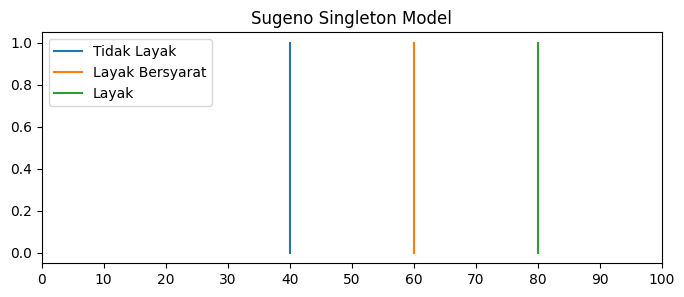

In [14]:
# Diagram Sugeno Singleton Model
plt.figure(figsize=(8,3))
plt.title("Sugeno Singleton Model")
plt.plot([40,40],[0,1], label="Tidak Layak")
plt.plot([60,60],[0,1], label="Layak Bersyarat")
plt.plot([80,80],[0,1], label="Layak")
plt.xticks(np.arange(0, 101, 10))
plt.legend()
plt.savefig("sugeno.png", dpi=300)
plt.show()

In [15]:
deffuzy = {'Tidak Layak': 40, 'Layak Bersyarat': 60, 'Layak': 80}

def defuzzification(inference, deffuzy):
    num, den = 0, 0
    for output in deffuzy:
        num += inference[output] * deffuzy[output]
        den += inference[output]
    return num / den if den != 0 else 0

hasilAkhir = [defuzzification(i, deffuzy) for i in hasilInferensi]

In [16]:
print("\nContoh Hasil Defuzzifikasi:\n")
for i in range(0, 10):
    print(f"Data ke-{i+1}: {hasilAkhir[i]:.2f}")


Contoh Hasil Defuzzifikasi:

Data ke-1: 40.00
Data ke-2: 57.31
Data ke-3: 78.46
Data ke-4: 55.00
Data ke-5: 62.40
Data ke-6: 67.50
Data ke-7: 80.00
Data ke-8: 72.50
Data ke-9: 45.20
Data ke-10: 80.00


In [17]:
# Menampilkan hasil akhir
kredit['kelayakan'] = hasilAkhir

# Urutkan berdasarkan kelayakan (descending)
peringkat = kredit.sort_values(by='kelayakan', ascending=False).head(10)
peringkat = peringkat.reset_index(drop=True)
peringkat.index += 1

from IPython.display import display, HTML

print("Nasabah Layak Kartu Kredit")
display(HTML(peringkat[['id', 'pendapatan', 'pengeluaran', 'kelayakan']].to_html(index=True)))

Nasabah Layak Kartu Kredit


,id,pendapatan,pengeluaran,kelayakan
1,7,18.5,7.2,80.000000
2,10,13.7,4.0,80.000000
3,3,12.0,4.2,78.461538
4,8,10.1,5.5,72.500000
5,6,15.0,10.5,67.500000
6,5,5.6,3.0,62.400000
7,2,7.2,6.5,57.309091
8,4,9.8,9.0,55.000000
9,9,6.3,8.5,45.200000
10,1,3.5,8.0,40.000000
